# 08 - SARIMA Full Dataset Case

**Muc tieu cua phan nay:**
1. Fit SARIMA/SARIMAX tren toan bo chuoi thoi gian cua moi series hien co, khong cat 80/20 nhu notebook `06`-`07`.
2. Giup giai thich bai toan classical model theo cach khoa hoc hon cho full-case: so sanh ARIMA va SARIMA bang **AIC/BIC**, sai so in-sample (**RMSE, MAE**) va kiem dinh phan du (**Ljung-Box**).
3. Giu cau truc thao tac tuong tu notebook cu, nhung toan bo logic duoc tach ra file moi `src/ds003029_eda/sarima_full.py` va `tools/train_sarima_full_dataset.py`.


In [4]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ws = Path.cwd().resolve()
src_dir = (ws / 'src' if (ws / 'src').exists() else ws.parent / 'src').resolve()
sys.path.insert(0, str(src_dir))

from ds003029_eda.paths import get_paths
from ds003029_eda.sarima_full import run_full_sarima_pipeline

paths = get_paths()
prepared, df_metrics = run_full_sarima_pipeline(
    feature_path=None,
    n_lags=2,
    output_subdir='sarima_full_case',
    paths=paths,
)

output_dir = paths.outputs_dir / 'sarima_full_case'
df_predictions = pd.read_csv(output_dir / 'sarima_full_all_predictions.csv')

print('So dong du lieu sau khi tao lags:', len(prepared.df))
print('So series duoc xu ly:', prepared.df[prepared.series_col].nunique())
display(df_metrics)


So dong du lieu sau khi tao lags: 139
So series duoc xu ly: 1


,series_id,n_obs,cadence_s,target_col,exog_cols,selected_order,selected_seasonal_order,baseline_order,baseline_aic,sarima_aic,baseline_bic,sarima_bic,rmse_arima,rmse_sarima,mae_arima,mae_sarima,ljungbox_pvalue_arima,ljungbox_pvalue_sarima,status,notes
0,C:\Users\admin\OneDrive - National Economics U...,139,1.0,rms,"[ptp, line_length, rms_lag_1, rms_lag_2]","(1, 0, 0)","(0, 0, 0, 0)","(1, 0, 1)",-2520.509384,-2613.003863,-2497.033592,-2592.513087,0.000025,0.000018,0.00002,0.000012,2.347895e-13,0.041585,ok,Full-sequence fit without train/test split. Mo...


## Tong hop khoa hoc

- `selected_order` va `selected_seasonal_order` la cau hinh duoc chon theo AIC thap nhat trong mot luoi tham so gon nhe.
- `candidate_seasonal_periods` va `selected_seasonal_period_steps` duoc tinh theo so buoc thoi gian cua chuoi. Neu can doi sang giay, dung cong thuc `selected_seasonal_period_steps * cadence_s`.
- `selected_seasonal_period_seconds` la ban quy doi ra giay khi cadence co the uoc luong duoc. Gia tri nay khong co nghia la "moi X giay co 1 con dong kinh".
- `rmse_sarima` va `mae_sarima` la sai so fitted tren full sequence, phu hop cho full-case khi muc tieu la mo ta va hoan thien mo hinh co dien.
- `ljungbox_pvalue_sarima` lon hon cho thay phan du it tuong quan noi tiep hon, tuc mo hinh giai thich tot hon cau truc dong hoc con lai.


In [5]:
ok_metrics = df_metrics[df_metrics['status'] == 'ok'].copy()
if not ok_metrics.empty:
    summary = pd.DataFrame([
        {
            'mean_rmse_arima': ok_metrics['rmse_arima'].mean(),
            'mean_rmse_sarima': ok_metrics['rmse_sarima'].mean(),
            'mean_mae_arima': ok_metrics['mae_arima'].mean(),
            'mean_mae_sarima': ok_metrics['mae_sarima'].mean(),
            'mean_aic_gap_arima_minus_sarima': (ok_metrics['baseline_aic'] - ok_metrics['sarima_aic']).mean(),
        }
    ])
    display(summary)
else:
    print('Khong co series nao fit thanh cong. Hay kiem tra metrics CSV trong eda_outputs/sarima_full_case/.')


,mean_rmse_arima,mean_rmse_sarima,mean_mae_arima,mean_mae_sarima,mean_aic_gap_arima_minus_sarima
0,0.000025,0.000018,0.00002,0.000012,92.49448


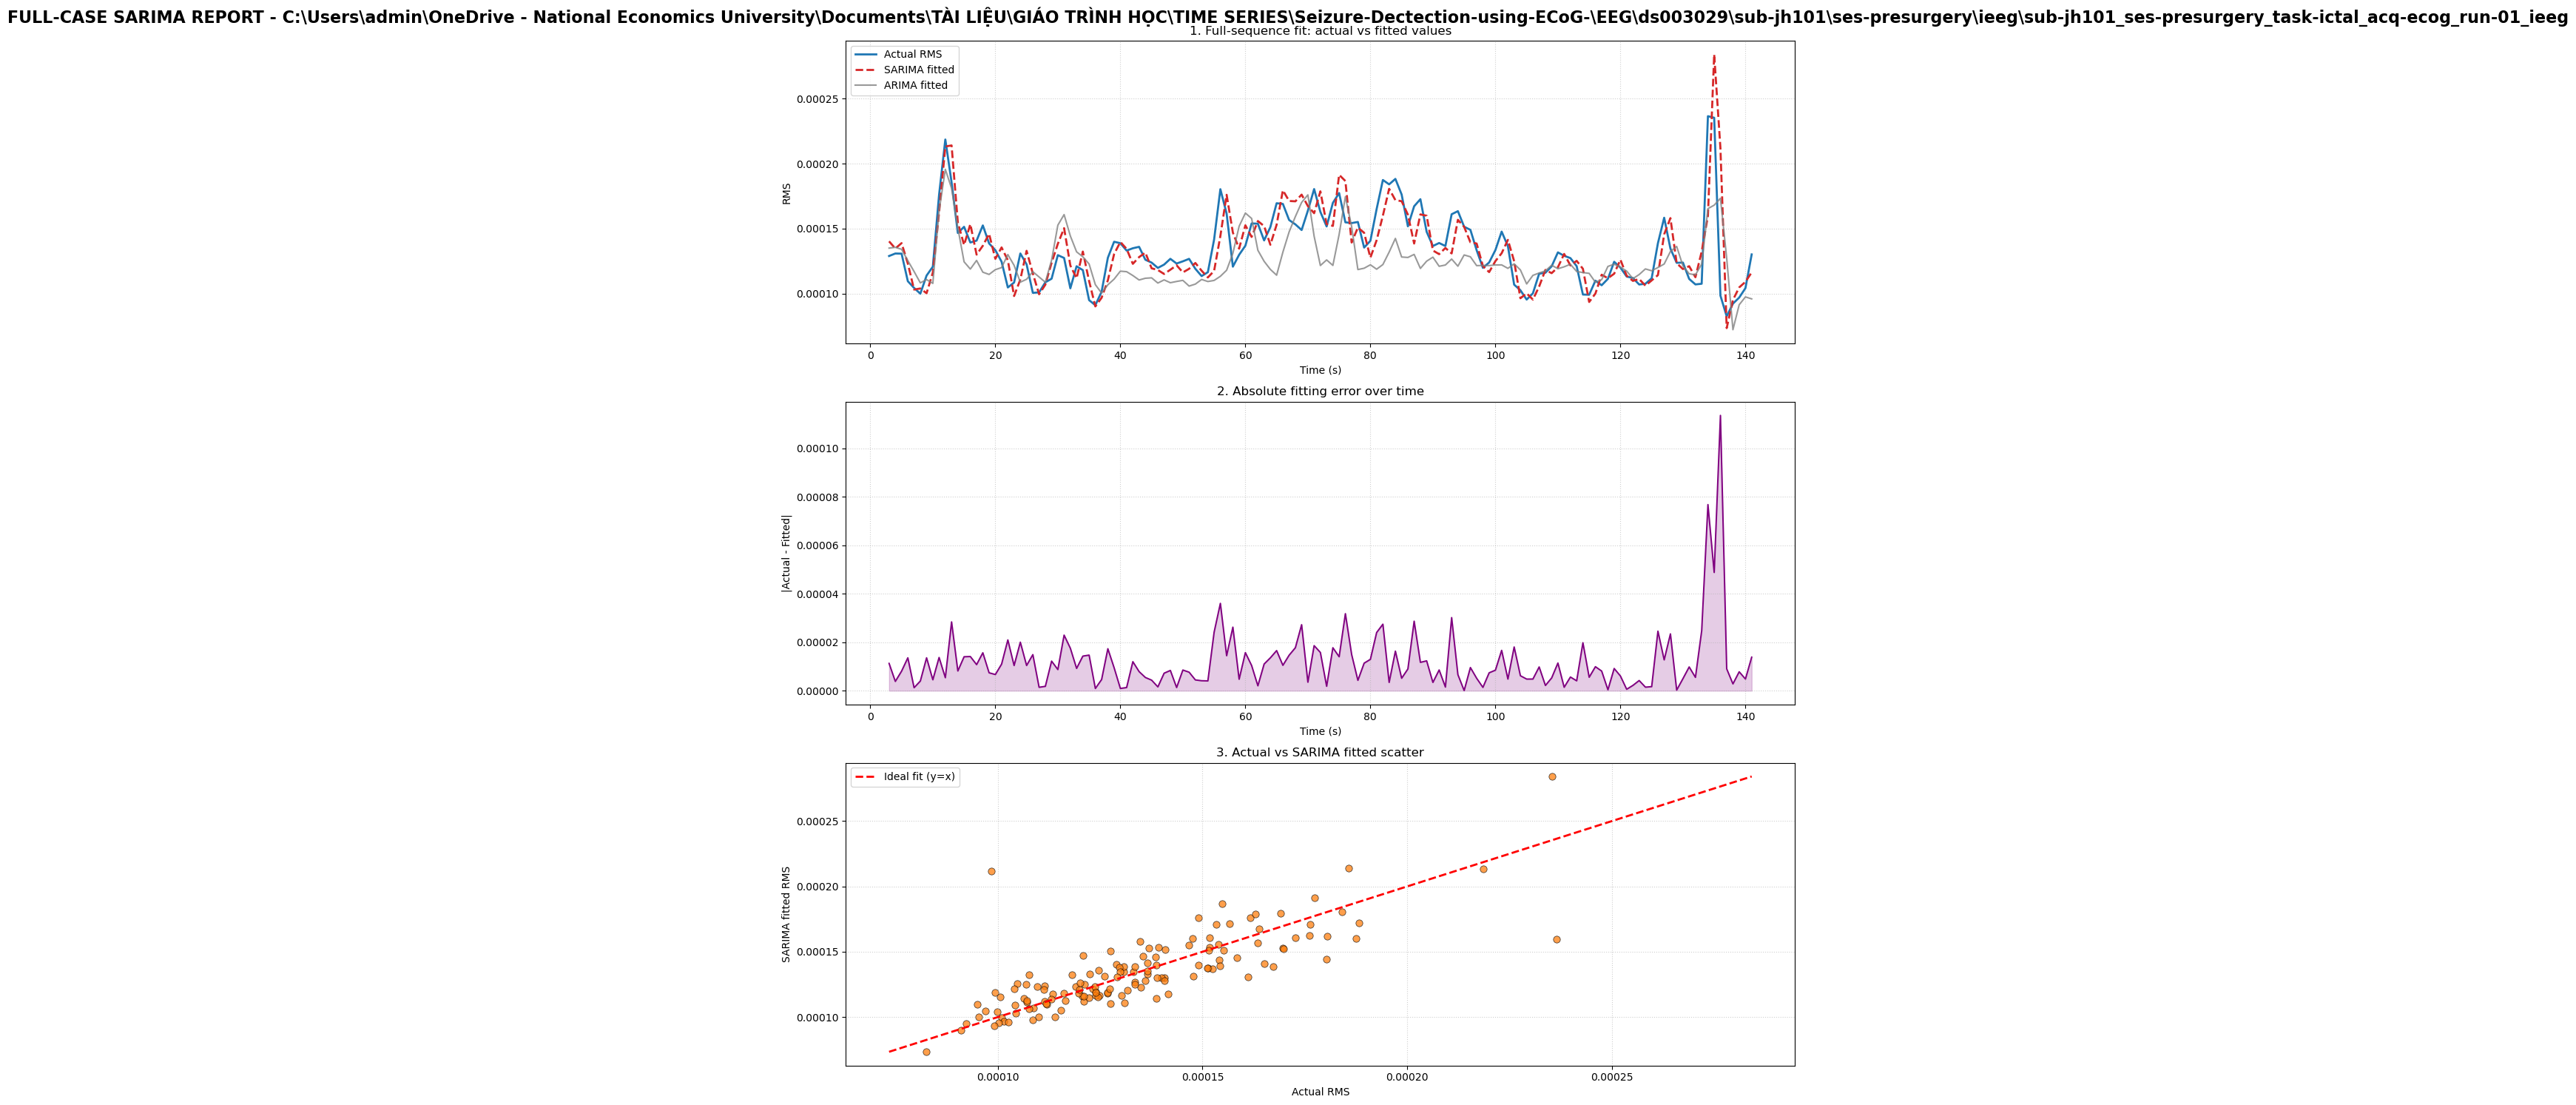

In [6]:
if not df_predictions.empty:
    first_series = df_predictions['series_id'].iloc[0]
    df_plot = df_predictions[df_predictions['series_id'] == first_series].copy()
    df_plot['sarima_abs_error'] = (df_plot['rms'] - df_plot['sarima_fitted']).abs()

    fig, axes = plt.subplots(3, 1, figsize=(14, 16))
    fig.suptitle(f'FULL-CASE SARIMA REPORT - {first_series}', fontsize=16, fontweight='bold', y=0.93)

    axes[0].plot(df_plot['t_mid_s'], df_plot['rms'], label='Actual RMS', color='#1f77b4', linewidth=2)
    axes[0].plot(df_plot['t_mid_s'], df_plot['sarima_fitted'], label='SARIMA fitted', color='#d62728', linestyle='--', linewidth=2)
    axes[0].plot(df_plot['t_mid_s'], df_plot['arima_fitted'], label='ARIMA fitted', color='gray', alpha=0.8)
    axes[0].set_title('1. Full-sequence fit: actual vs fitted values')
    axes[0].set_xlabel('Time (s)')
    axes[0].set_ylabel('RMS')
    axes[0].legend(loc='upper left')
    axes[0].grid(True, linestyle=':', alpha=0.6)

    axes[1].plot(df_plot['t_mid_s'], df_plot['sarima_abs_error'], color='purple', linewidth=1.4)
    axes[1].fill_between(df_plot['t_mid_s'], df_plot['sarima_abs_error'], color='purple', alpha=0.2)
    axes[1].set_title('2. Absolute fitting error over time')
    axes[1].set_xlabel('Time (s)')
    axes[1].set_ylabel('|Actual - Fitted|')
    axes[1].grid(True, linestyle=':', alpha=0.6)

    sns.scatterplot(data=df_plot, x='rms', y='sarima_fitted', ax=axes[2], color='#ff7f0e', edgecolor='k', s=45, alpha=0.75)
    min_val = min(df_plot['rms'].min(), df_plot['sarima_fitted'].min())
    max_val = max(df_plot['rms'].max(), df_plot['sarima_fitted'].max())
    axes[2].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Ideal fit (y=x)')
    axes[2].set_title('3. Actual vs SARIMA fitted scatter')
    axes[2].set_xlabel('Actual RMS')
    axes[2].set_ylabel('SARIMA fitted RMS')
    axes[2].legend()
    axes[2].grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
else:
    print('Khong co du lieu predictions de ve bieu do.')
